# BERT Sentiment Analysis for Airbnb Reviews

This notebook performs sentiment analysis on Airbnb reviews using a pre-trained BERT model from Hugging Face.

## 1. Import Required Libraries

Import necessary libraries including transformers, torch, numpy, and pandas for BERT sentiment analysis.

In [26]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

Using device: CPU


## 2. Load Pre-trained BERT Model and Tokenizer

Load a pre-trained BERT model and tokenizer from the Hugging Face transformers library suitable for sentiment analysis tasks.

In [27]:
# Load pre-trained BERT model for sentiment analysis
# Using multilingual BERT for better language support
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=device)

print(f"Model: {model_name}")
print(f"Tokenizer: {model_name}")

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Device set to use cpu


Model: nlptown/bert-base-multilingual-uncased-sentiment
Tokenizer: nlptown/bert-base-multilingual-uncased-sentiment


## 3. Prepare Text Data

Load and prepare your text dataset, including cleaning and formatting the data for analysis.

In [28]:
# Load reviews data from CSV
reviews_df = pd.read_csv('./data/reviews_select.csv', nrows=1000)
print(f"Dataset shape: {reviews_df.shape}")
print(f"\nFirst few rows:")
print(reviews_df.head())
print(f"\nColumn names: {reviews_df.columns.tolist()}")
print(f"\nData types:\n{reviews_df.dtypes}")
print(f"\nMissing values:\n{reviews_df.isnull().sum()}")

Dataset shape: (1000, 10)

First few rows:
   Unnamed: 0  listing_id                  id        date  reviewer_id  \
0           1        5396  916489788146905600  2023-06-18    497745629   
1           2        5396  921600086982789760  2023-06-25     70206366   
2           3        5396  926663219961790080  2023-07-02     41320355   
3           4        5396  928819963905476608  2023-07-05    259277676   
4           5        5396  929517734275725952  2023-07-06     93503104   

  reviewer_name                                           comments langue  \
0        Grazia  Alloggio confortevole e pratico, dotato di tut...     it   
1      Benjamin  Très bon emplacement pour cet appartement typi...     fr   
2         Julia  What a wonderful gem.  Great location, it was ...     en   
3         GLori  We had a lovely 3 night stay.  Everything was ...     en   
4         James  Great location. Very calm and quiet. Small but...     en   

  langue_short  nwords  
0        Latin      18  

In [29]:
# Data cleaning and preparation
# Remove rows with missing review text
reviews_df = reviews_df.dropna(subset=['comments'])

# Convert to string type
reviews_df['comments'] = reviews_df['comments'].astype(str)

# Remove empty strings
reviews_df = reviews_df[reviews_df['comments'].str.strip() != '']

# Remove duplicates
reviews_df = reviews_df.drop_duplicates(subset=['comments'])

# Limit text length to 512 tokens (BERT max)
reviews_df['comments'] = reviews_df['comments'].apply(lambda x: x[:512])

print(f"Cleaned dataset shape: {reviews_df.shape}")
print(f"Sample reviews:")
print(reviews_df['comments'].head(3).values)

Cleaned dataset shape: (1000, 10)
Sample reviews:
['Alloggio confortevole e pratico, dotato di tutto quello che serve. Nonostante sia situato in centro è molto silenzioso.'
 'Très bon emplacement pour cet appartement typique au cœur d une belle vie de quartier  tout en se préservant du calme. Hyper central pour visiter la capitale'
 'What a wonderful gem.  Great location, it was spotless and the studio was recently renovated. Even a new sofa bed.  We thoroughly enjoyed our stay and highly recommend.']


## 4. Tokenize and Encode Text

Use the BERT tokenizer to tokenize and encode text samples into token IDs and attention masks.

In [30]:
# Tokenize the text
texts = reviews_df['comments'].tolist()

# Example tokenization of first review
sample_text = texts[0]
tokens = tokenizer.tokenize(sample_text[:200])
print(f"Sample text: {sample_text[:200]}")
print(f"Tokens: {tokens}")
print(f"Number of tokens: {len(tokens)}")

# Encode texts
print("\nEncoding all texts...")
encodings = tokenizer(texts, truncation=True, max_length=512, padding=True, return_tensors='pt')

print(f"Encoded shape - input_ids: {encodings['input_ids'].shape}")
print(f"Encoded shape - attention_mask: {encodings['attention_mask'].shape}")

Sample text: Alloggio confortevole e pratico, dotato di tutto quello che serve. Nonostante sia situato in centro è molto silenzioso.
Tokens: ['allo', '##ggio', 'con', '##forte', '##vole', 'e', 'prat', '##ico', ',', 'dotato', 'di', 'tutto', 'quello', 'che', 'serve', '.', 'nonostante', 'sia', 'situato', 'in', 'centro', 'e', 'molto', 'sile', '##nzio', '##so', '.']
Number of tokens: 27

Encoding all texts...
Encoded shape - input_ids: torch.Size([1000, 281])
Encoded shape - attention_mask: torch.Size([1000, 281])


## 5. Generate BERT Embeddings

Pass the tokenized text through the BERT model to generate embeddings and extract features.

In [31]:
# Move model to device
model = model.to(device if device == 0 else 'cpu')
model.eval()

# Generate embeddings
print("Generating BERT embeddings...")
with torch.no_grad():
    outputs = model(**encodings, output_hidden_states=True)
    
# Extract embeddings from last hidden state
embeddings = outputs.hidden_states[-1].cpu().numpy()  # Shape: (batch_size, sequence_length, hidden_size)
cls_embeddings = embeddings[:, 0, :]  # Extract [CLS] token embeddings (batch_size, hidden_size)

print(f"Embeddings shape: {embeddings.shape}")
print(f"CLS embeddings shape: {cls_embeddings.shape}")
print(f"\nFirst embedding (first 10 dimensions):")
print(cls_embeddings[0][:10])

Generating BERT embeddings...
Embeddings shape: (1000, 281, 768)
CLS embeddings shape: (1000, 768)

First embedding (first 10 dimensions):
[ 0.18021303 -0.82333285 -0.34045604 -0.1059067   0.6010686   0.00648674
  0.07311425 -0.01700119  0.6139146   0.60736954]


## 6. Classify Sentiment

Use the generated embeddings to classify sentiment (positive, negative, neutral) for each text sample.

In [32]:
# Classify sentiment for all reviews using the pipeline
print("Classifying sentiment...")
sentiments = sentiment_pipeline(texts)

# Extract sentiment labels and scores
sentiment_labels = [s['label'] for s in sentiments]
sentiment_scores = [s['score'] for s in sentiments]

# Add to dataframe
reviews_df['sentiment'] = sentiment_labels
reviews_df['sentiment_score'] = sentiment_scores

print(f"\nSentiment Classification Results:")
print(reviews_df[['comments', 'sentiment', 'sentiment_score']].head(10))

# Sentiment distribution
print(f"\nSentiment Distribution:")
print(reviews_df['sentiment'].value_counts())
print(f"\nSentiment Proportions:")
print(reviews_df['sentiment'].value_counts(normalize=True))

Classifying sentiment...

Sentiment Classification Results:
                                            comments sentiment  \
0  Alloggio confortevole e pratico, dotato di tut...   5 stars   
1  Très bon emplacement pour cet appartement typi...   5 stars   
2  What a wonderful gem.  Great location, it was ...   5 stars   
3  We had a lovely 3 night stay.  Everything was ...   5 stars   
4  Great location. Very calm and quiet. Small but...   5 stars   
5  we loved this apartment, very convenient, easy...   5 stars   
6  Awesome communication via texting to insure an...   5 stars   
7                               Nice place best spot   5 stars   
8  Lovely home in a quaint and serene neighborhoo...   5 stars   
9  Borzou’s apartment is, in my humble opinion, i...   4 stars   

   sentiment_score  
0         0.474794  
1         0.535976  
2         0.964736  
3         0.721059  
4         0.665904  
5         0.512579  
6         0.865477  
7         0.656274  
8         0.579621  
9  

## 7. Evaluate Model Performance and Visualize Results

Evaluate the sentiment classification results and create visualizations.

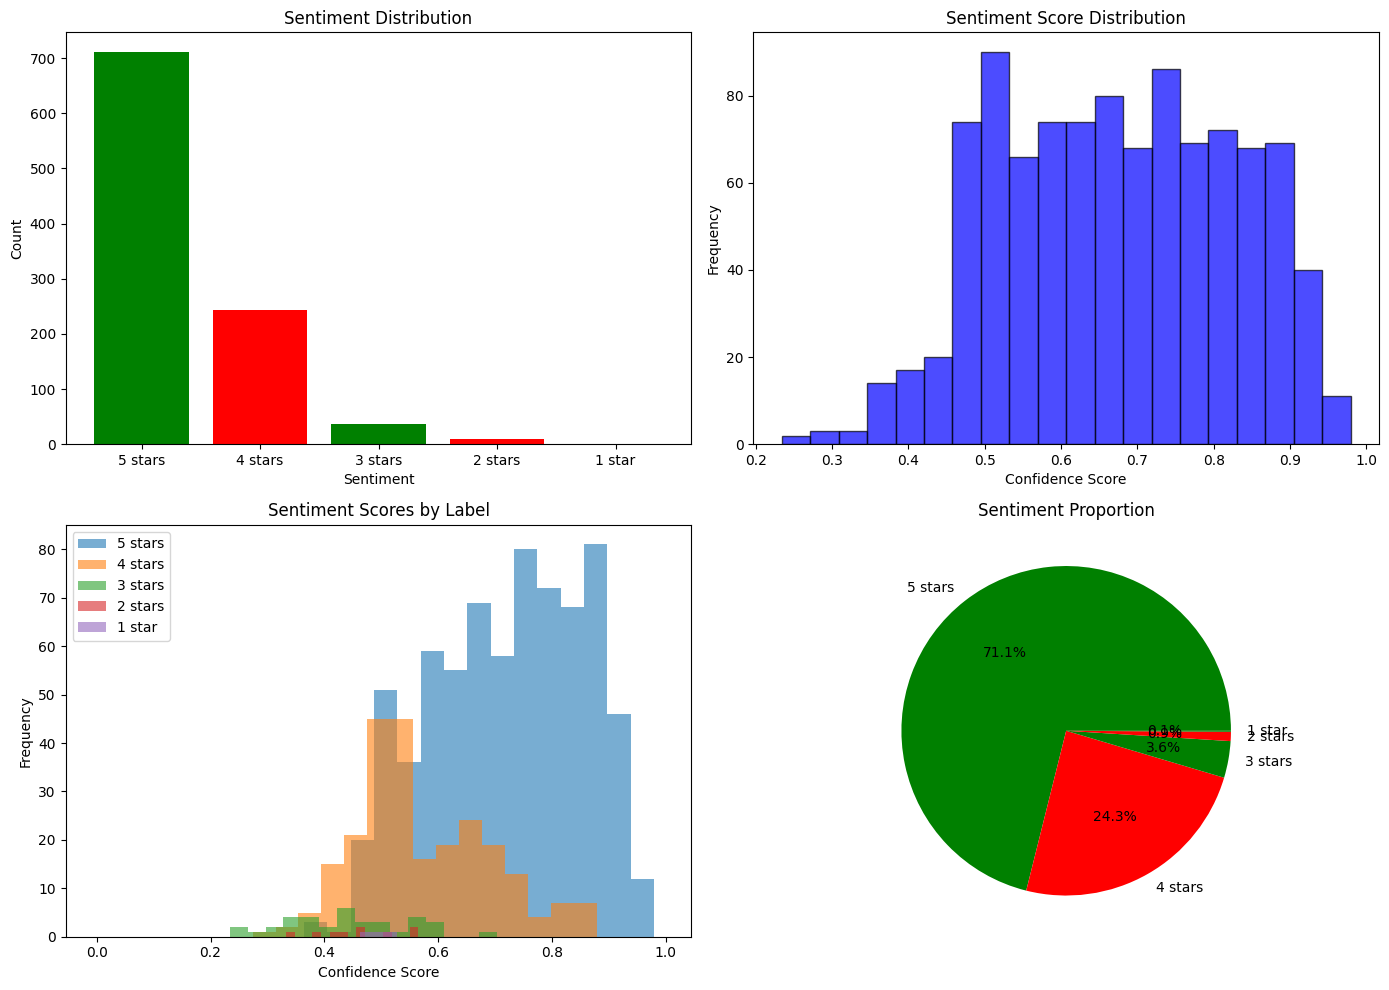


SUMMARY STATISTICS
Total reviews analyzed: 1000
Average sentiment score: 0.6725
Max sentiment score: 0.9795
Min sentiment score: 0.2341

Sentiment breakdown:
  5 stars: 711 (71.1%) - Avg Score: 0.7210
  4 stars: 243 (24.3%) - Avg Score: 0.5734
  3 stars: 36 (3.6%) - Avg Score: 0.4406
  2 stars: 9 (0.9%) - Avg Score: 0.4597
  1 star: 1 (0.1%) - Avg Score: 0.4953


In [33]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sentiment Distribution Bar Chart
sentiment_counts = reviews_df['sentiment'].value_counts()
axes[0, 0].bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red'])
axes[0, 0].set_title('Sentiment Distribution')
axes[0, 0].set_xlabel('Sentiment')
axes[0, 0].set_ylabel('Count')

# 2. Sentiment Scores Distribution
axes[0, 1].hist(reviews_df['sentiment_score'], bins=20, color='blue', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Sentiment Score Distribution')
axes[0, 1].set_xlabel('Confidence Score')
axes[0, 1].set_ylabel('Frequency')

# 3. Sentiment Scores by Label
for sentiment in reviews_df['sentiment'].unique():
    scores = reviews_df[reviews_df['sentiment'] == sentiment]['sentiment_score']
    axes[1, 0].hist(scores, bins=15, alpha=0.6, label=sentiment)
axes[1, 0].set_title('Sentiment Scores by Label')
axes[1, 0].set_xlabel('Confidence Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# 4. Pie Chart
axes[1, 1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
               colors=['green', 'red'])
axes[1, 1].set_title('Sentiment Proportion')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(f"Total reviews analyzed: {len(reviews_df)}")
print(f"Average sentiment score: {reviews_df['sentiment_score'].mean():.4f}")
print(f"Max sentiment score: {reviews_df['sentiment_score'].max():.4f}")
print(f"Min sentiment score: {reviews_df['sentiment_score'].min():.4f}")
print(f"\nSentiment breakdown:")
for sentiment in reviews_df['sentiment'].unique():
    count = len(reviews_df[reviews_df['sentiment'] == sentiment])
    percentage = (count / len(reviews_df)) * 100
    avg_score = reviews_df[reviews_df['sentiment'] == sentiment]['sentiment_score'].mean()
    print(f"  {sentiment}: {count} ({percentage:.1f}%) - Avg Score: {avg_score:.4f}")

## 8. Save Results to CSV

Save the sentiment analysis results to a CSV file.

In [34]:
# Save results to CSV file
output_filename = 'sentiment_analysis_results.csv'
reviews_df.to_csv(output_filename, index=False, encoding='utf-8')

print(f"Results saved to: {output_filename}")
print(f"Total records saved: {len(reviews_df)}")

# Display preview of saved data
print(f"\nPreview of saved data:")
print(reviews_df[['comments', 'sentiment', 'sentiment_score']].head(1000))

Results saved to: sentiment_analysis_results.csv
Total records saved: 1000

Preview of saved data:
                                              comments sentiment  \
0    Alloggio confortevole e pratico, dotato di tut...   5 stars   
1    Très bon emplacement pour cet appartement typi...   5 stars   
2    What a wonderful gem.  Great location, it was ...   5 stars   
3    We had a lovely 3 night stay.  Everything was ...   5 stars   
4    Great location. Very calm and quiet. Small but...   5 stars   
..                                                 ...       ...   
995  A lakás pontosan olyan mint a hirdetésben, jól...   5 stars   
996  Carol fue muy amable en todo momento , incluso...   5 stars   
997  We loved staying in this apartment! This place...   4 stars   
998  Great little spot for two in the 9th, super co...   5 stars   
999  Het meest positieve aan de kamer is de locatie...   2 stars   

     sentiment_score  
0           0.474794  
1           0.535976  
2           0.9